# Instruction for South Polar Projrction Mapping

In [8]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs 
import xarray as xr
import numpy as np 
import occ


In [9]:
%matplotlib inline                           
%config InlineBackend.figure_format='retina' 
plt.rcParams['figure.figsize'] = 8,4  
plt.rcParams['figure.dpi'] = 300

In [10]:
# Load OISST climate mean data

SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc', use_cftime=True)
SST_OISST

/var/folders/y3/jjb7h7fd4mg_yy8nsvfhwzym0000gn/T/ipykernel_83941/1239048586.py:3: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  SST_OISST = xr.open_dataset('sst.oisst.mon.ltm.1991-2020.nc', use_cftime=True)


<xarray.Dataset> Size: 6MB
Dimensions:             (lat: 180, lon: 360, time: 12, nbnds: 2)
Coordinates:
  * lat                 (lat) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                 (lon) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
  * time                (time) object 96B 1991-01-01 00:00:00 ... 1991-12-01 ...
Dimensions without coordinates: nbnds
Data variables:
    climatology_bounds  (time, nbnds) object 192B ...
    sst                 (time, lat, lon) float32 3MB ...
    valid_yr_count      (time, lat, lon) float32 3MB ...
Attributes: (12/13)
    CDI:                            Climate Data Interface version 1.9.10 (ht...
    source:                         NOAA/NCEI https://www.ncei.noaa.gov/data/...
    institution:                    NOAA/National Centers for Environmental I...
    Conventions:                    CF-1.5
    title:                          NOAA/NCEI 1/4 Degree Daily Optimum Interp...
    References:                     https://www.psl.noaa.gov/data/gridded/dat...
    ...                             ...
    version:                        Version 2.1
    comment:                        Reynolds, et al.(2007) Daily High-Resolut...
    CDO:                            Climate Data Operators version 1.9.10 (ht...
    history:                        Created 2023/08/08 by doMonthLTMNC4
    NCO:                            netCDF Operators version 4.8.1 (Homepage ...
    not_missing_threshold_percent:  minimum 3% values input to have non-missi...

In [11]:
SST_1991 = SST_OISST.sst.sel(time='1991-01-01')
SST_1991

<xarray.DataArray 'sst' (time: 1, lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * time     (time) object 8B 1991-01-01 00:00:00
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      Monthly Long Term Mean of Sea Surface Temperature
    units:          degC
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Long Term Mean
    parent_stat:    Monthly Mean
    actual_range:   [-1.796084 34.121593]

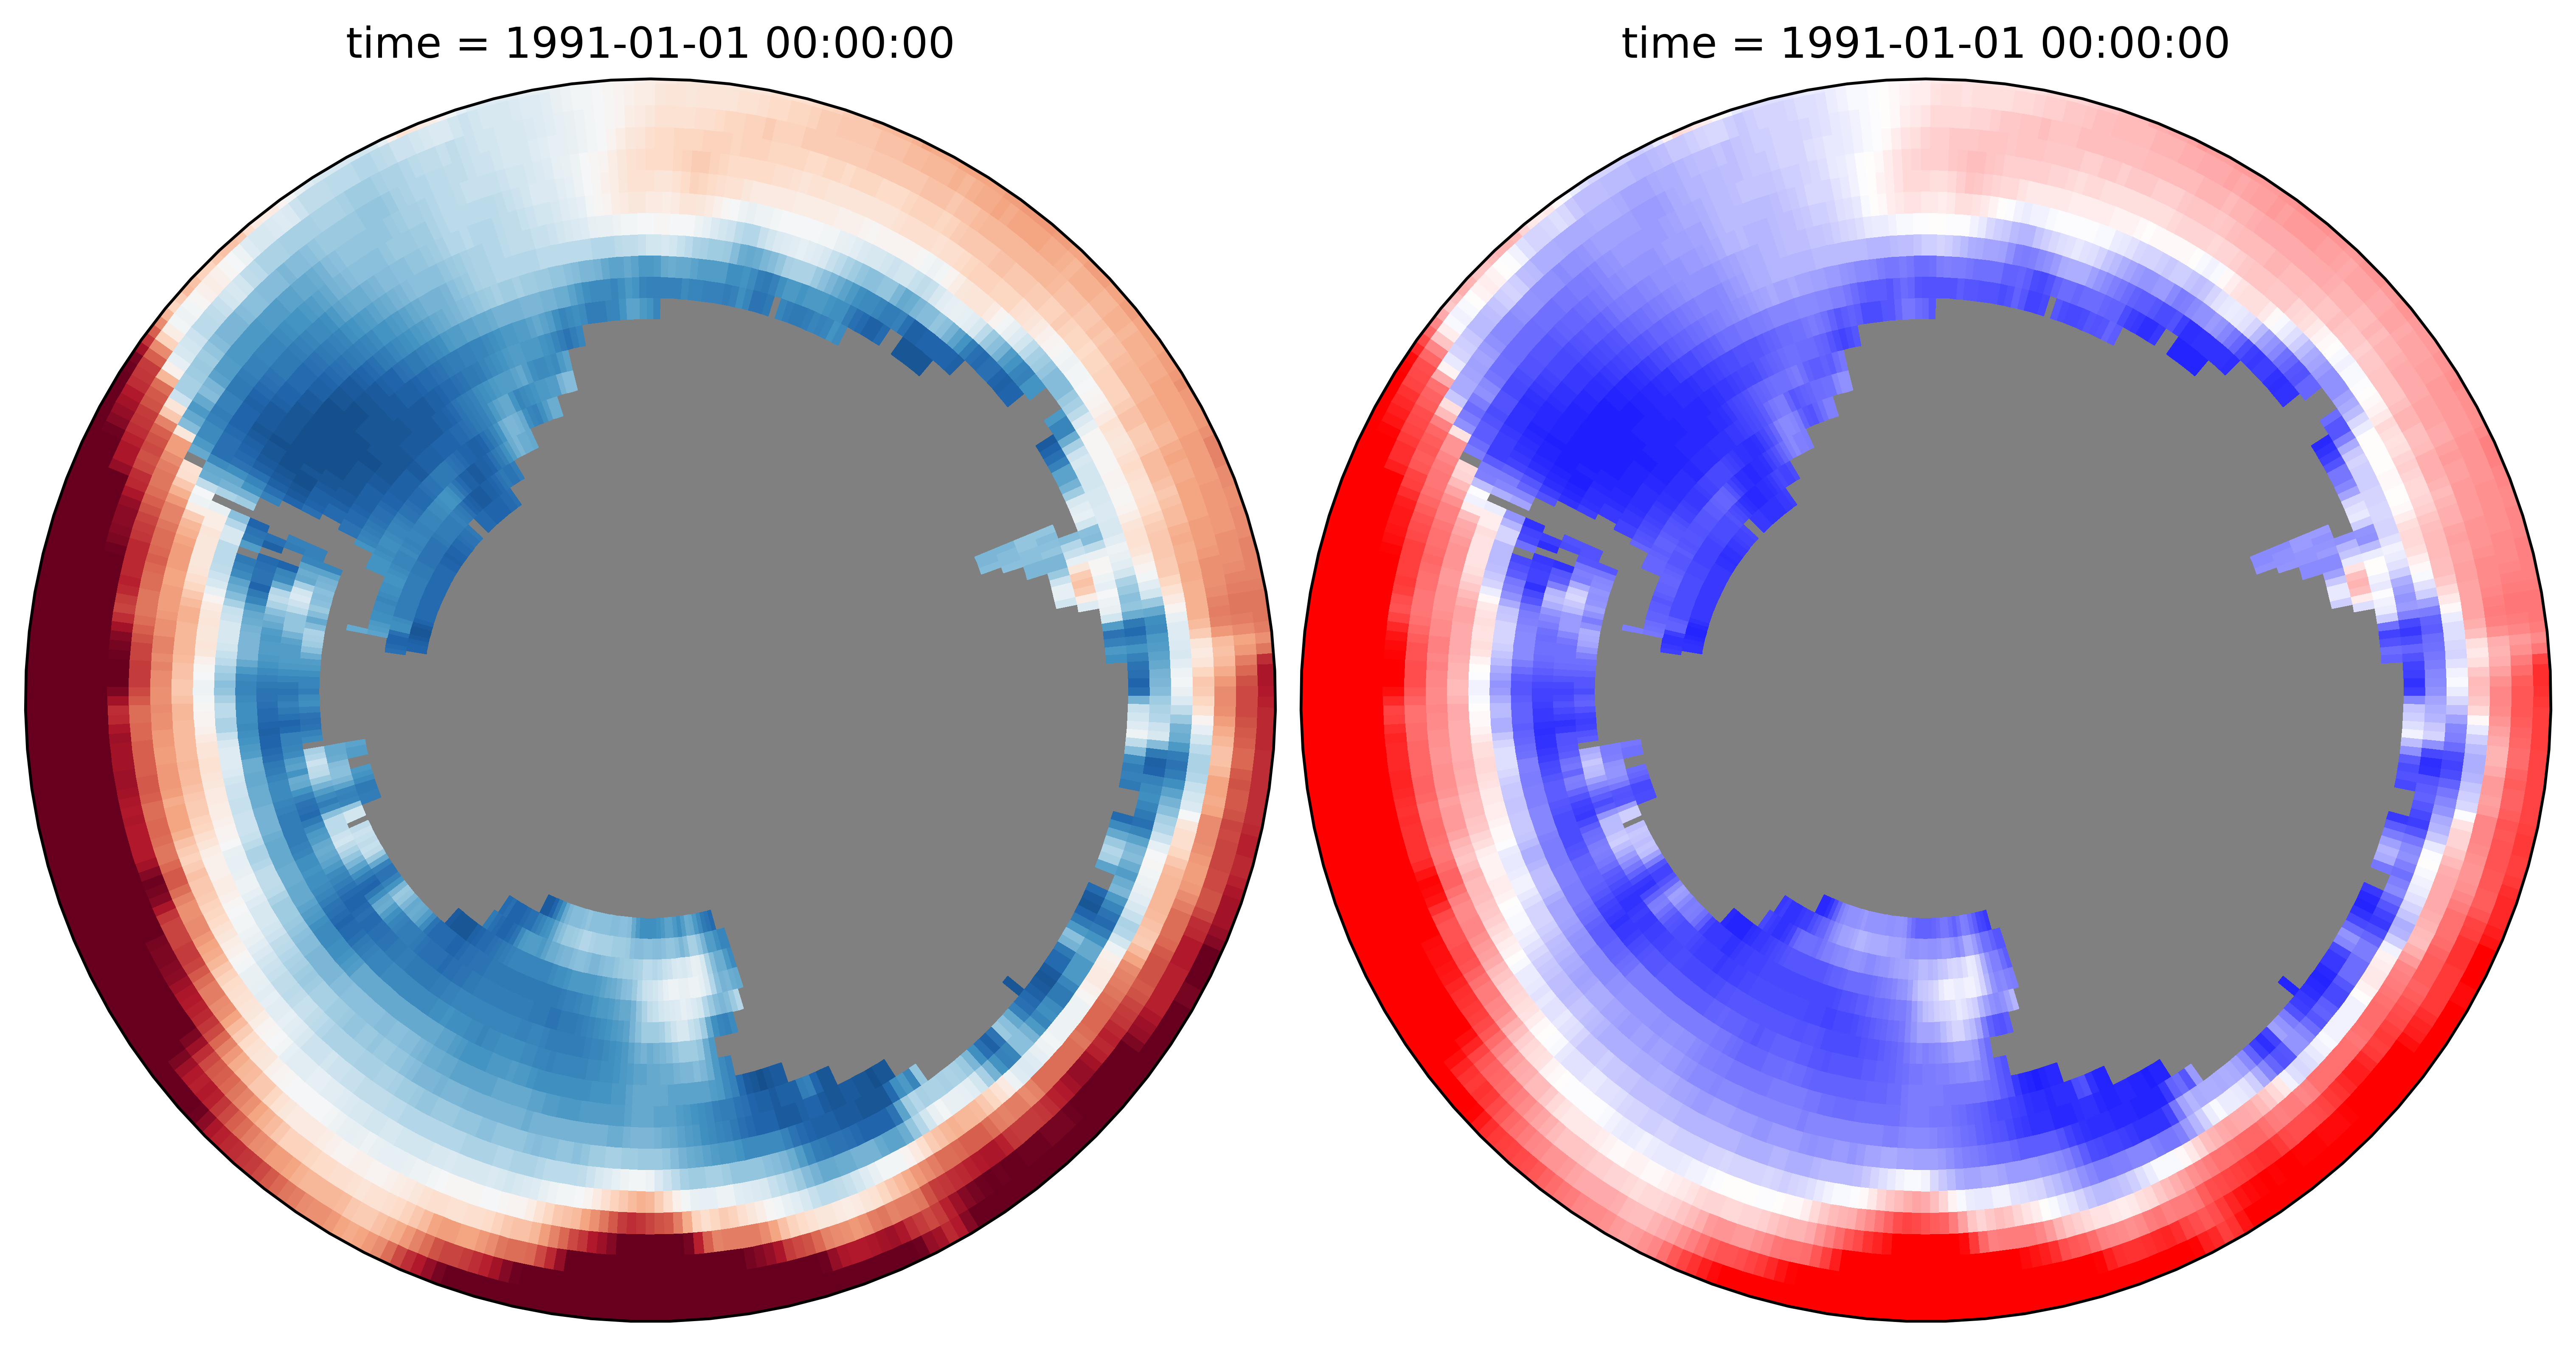

In [ ]:
fig , ax = occ.maps.south_pole_map(cols=2, rows=1, fig_size=(10,20), max_extent=-60, facecolor='grey')

SST_1991.plot(ax=ax[0], transform=ccrs.PlateCarree(), vmin=-2, vmax=2, add_colorbar = False, levels=100, cmap='RdBu_r')
SST_1991.plot(ax=ax[1], transform=ccrs.PlateCarree(), vmin=-2, vmax=2, add_colorbar = False, levels=100, cmap='bwr')
